# Exact Gibb Sampler

In [8]:
import jax
import jax.numpy as jnp

import numpy as np 
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt

## Creating the sample Y

In [9]:
def create_Y(key, n, L, theta):
    mu, sig2 = theta
    X = jnp.exp(mu + jnp.sqrt(sig2)*jax.random.normal(key, shape=(n,L)))
    Y = jnp.sum(X, axis=1)
    return Y

key = jax.random.PRNGKey(0)
theta = 0., 0.09
L = 10
n = 10000

Y = create_Y(key, n, L, theta)


<Axes: ylabel='Count'>

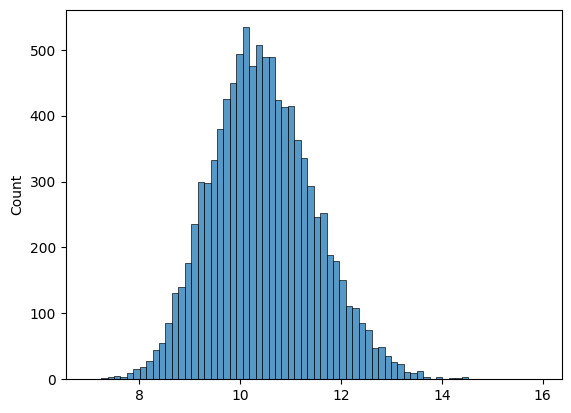

In [10]:
Y.shape
sns.histplot(Y)

# Deriving and Implementing the Exact Gibbs Sampler via Data Augmentation

## 1. Problem Formulation and The Augmented Posterior

We observe $n$ data points $Y = (Y_i)_{1 \le i \le n}$, where each $Y_i$ is generated by a sum of $L$ exponentiated log-normal random variables:
$$Y_i = \sum_{l=1}^L \exp(X_{i,l})$$
where the latent variables are $X_{i,l} \sim_{iid} \mathcal{N}(\mu, \sigma^2)$. Our goal is to infer the parameters $\theta = (\mu, \sigma^2)$.

The direct posterior is given by Bayes' Theorem:
$$p(\theta | Y) \propto \pi(\theta) p(Y|\theta)$$
However, evaluating $p(Y|\theta)$ requires computing an intractable $L$-dimensional integral over the continuous latent space of $X$. Standard Metropolis-Hastings on $\theta$ directly is thus impossible.

To circumvent this, we used **Data Augmentation**. By treating the unobserved latent variables $X = \{X_{i,l}\}$ as auxiliary parameters, we augment the target space from $\theta$ to $(\theta, X)$. The augmented posterior becomes:
$$p(\theta, X | Y) \propto \pi(\theta, X) p(Y | \theta, X)$$

Since the latent variables $X$ depend on $\theta$, the joint prior decomposes as $\pi(\theta, X) = \pi(\theta)p(X|\theta)$. Crucially, given the specific values of $X$, the observation $Y$ is completely deterministic. Thus, the likelihood $p(Y | \theta, X)$ collapses into a simple indicator function:
$$p(\theta, X | Y) \propto \pi(\theta) \left( \prod_{i=1}^n \prod_{l=1}^L \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(X_{i,l}-\mu)^2}{2\sigma^2}\right) \right) \prod_{i=1}^n \mathbb{I}\left(Y_i = \sum_{l=1}^L \exp(X_{i,l})\right)$$

### Why a Gibbs Sampler?
We cannot directly sample from $p(\theta, X | Y)$ because the indicator function creates a strict, zero-width support manifold, and the normalization constant is intractable. However, a **Gibbs sampler** is the perfect tool here. It allows us to sample sequentially from the *full conditional distributions*. This breaks the intractable joint problem into two highly tractable blocks:
1.  **Direct Marginal for $\theta$:** $p(\theta | X, Y)$
2.  **MH-within-Gibbs for $X$:** $p(X | \theta, Y)$

---


## 2. Block 1: The Direct Marginal Update for $\theta | X, Y$

Conditioned on the unobserved latent variables $X$, the deterministic constraint imposed by our observation $Y$ provides absolutely no additional information about the parameters $\theta$. Thus, the conditional posterior simplifies exactly to $p(\theta | X, Y) = p(\theta | X)$. 

To make this step analytically exact and avoid the computational burden of rejection sampling, we leverage **conjugate priors**. A prior is considered "conjugate" to a likelihood if multiplying them together yields a posterior belonging to the exact same probability distribution family. 

For the Gaussian likelihood of our latent variables $X_{i,l} \sim \mathcal{N}(\mu, \sigma^2)$, the conjugate prior for $\theta = (\mu, \sigma^2)$ is the **Normal-Inverse-Gamma (NIG)** distribution. We specify this prior with initial hyperparameters:
* $\sigma^2 \sim \text{IG}(a_0, b_0)$
* $\mu | \sigma^2 \sim \mathcal{N}(m_0, \sigma^2/\kappa_0)$

Because of conjugacy, multiplying this NIG prior by the Gaussian likelihood of the $N$ total latent variables (where $N = n \times L$) guarantees that the posterior $p(\theta | X)$ is also an NIG distribution. We simply need to update the hyperparameters using the empirical mean $\bar{X}$ and the sum of squared errors $S^2 = \sum(X - \bar{X})^2$.

The newly updated hyperparameters represent our data-informed distributions:
* **Updated Precision ($\kappa_n$):** $\kappa_n = \kappa_0 + N$. This represents our increased confidence in the mean after observing $N$ new data points.
* **Updated Mean ($m_n$):** $m_n = \frac{\kappa_0 m_0 + N \bar{X}}{\kappa_n}$. This is a weighted average, balancing our prior belief ($m_0$) against the empirical mean of the current $X$ states ($\bar{X}$).
* **Updated Shape ($a_n$):** $a_n = a_0 + \frac{N}{2}$. This updates the degrees of freedom for the variance based on the amount of data.
* **Updated Scale ($b_n$):** $b_n = b_0 + \frac{S^2}{2} + \frac{N \kappa_0}{2 \kappa_n} (\bar{X} - m_0)^2$. This incorporates the actual variance seen in the $X$ states ($S^2$) and an adjustment for how far the empirical mean shifted from our prior mean.

By analytically computing these parameters, we can draw exact, independent samples for $\sigma^2$ and then $\mu$ without requiring any Metropolis-Hastings acceptance steps.

---

## 3. Block 2: The Constrained Update for $X | \theta, Y$

The conditional distribution for the latent variables is:
$$p(X | \theta, Y) \propto p(X | \theta) \prod_{i=1}^n \mathbb{I}\left(Y_i = \sum_{l=1}^L \exp(X_{i,l})\right)$$

Because $Y_i$ strictly fixes the sum of the exponentiated terms, the components of each vector $X_i$ cannot be updated independently without breaking the constraint. To solve this, we utilize a **Pairwise Random Walk Metropolis (RWM)** step.

For a given observation $i$, we randomly select two indices $l$ and $l'$ (which we will denote as $x_1$ and $x_2$ for notational simplicity). We must update them such that their total sum remains strictly invariant:
$$s = \exp(x_1) + \exp(x_2) = \exp(x_1^{new}) + \exp(x_2^{new})$$

### The Change of Variables and Substitution
To propose a move without violating $s$, we define a bijection from the constrained 2D space $(x_1, x_2)$ to an unconstrained space defined by the sum $s$ and their difference $\delta$:
$$\delta = x_1 - x_2$$

We can propose a symmetric Gaussian random walk entirely in the unconstrained difference space: $\delta^{new} \sim \mathcal{N}(\delta^{curr}, \tau^2)$. To guarantee the constraint is maintained, we algebraically isolate $x_1$ and $x_2$ in terms of $s$ and $\delta$. 

Substituting $x_1 = x_2 + \delta$ into the sum equation gives:
$$s = \exp(x_2 + \delta) + \exp(x_2) = \exp(x_2)(\exp(\delta) + 1)$$
Solving for $x_2$ (and symmetrically for $x_1$) reveals the exact reverse-mapping:
$$x_2 = \log(s) - \log(1 + \exp(\delta))$$
$$x_1 = \log(s) - \log(1 + \exp(-\delta))$$
*(Note: $\log(1 + \exp(z))$ is exactly the definition of the `softplus` function, which guarantees numerical stability in implementation).*

### Rigorous Derivation of the Acceptance Ratio
Because we are performing a change of continuous variables, we must account for how the transformation warps the probability volume by computing the Jacobian matrix $J$ of the mapping $(x_1, x_2) \to (s, \delta)$:
$$J = \begin{pmatrix} \frac{\partial s}{\partial x_1} & \frac{\partial s}{\partial x_2} \\ \frac{\partial \delta}{\partial x_1} & \frac{\partial \delta}{\partial x_2} \end{pmatrix} = \begin{pmatrix} \exp(x_1) & \exp(x_2) \\ 1 & -1 \end{pmatrix}$$

The determinant of this transformation is $|J| = -\exp(x_1) - \exp(x_2) = -s$. 
Therefore, mapping *back* from the proposal space $(s, \delta)$ to the native parameter space $(x_1, x_2)$ requires the inverse Jacobian determinant, which is strictly $\frac{1}{s}$. The change of variables dictates that $dx_1 dx_2 = \frac{1}{s} ds d\delta$.

We can now rigorously construct the Metropolis-Hastings acceptance ratio $\alpha$. The ratio evaluates the target density $\pi$ in the native space, adjusted by the inverse Jacobian, multiplied by the proposal ratio $q$:

$$\alpha = \min\left(1, \frac{\pi(x_1^{new}, x_2^{new} | \theta) \cdot \left|\frac{1}{s^{new}}\right|}{\pi(x_1^{curr}, x_2^{curr} | \theta) \cdot \left|\frac{1}{s^{curr}}\right|} \times \frac{q(\delta^{curr} | \delta^{new})}{q(\delta^{new} | \delta^{curr})}\right)$$

This expression vastly simplifies due to two facts:
1.  **Symmetric Proposal:** Because we use a Gaussian random walk, $q(\delta^{curr} | \delta^{new}) = q(\delta^{new} | \delta^{curr})$, so the $q$ terms cancel out.
2.  **Strictly Invariant Sum:** By design, $s^{new} = s^{curr}$. Therefore, the Jacobian adjustments $\frac{1}{s}$ on the top and bottom perfectly cancel out.

Consequently, the acceptance probability relies *strictly* on the ratio of the native Gaussian prior densities evaluated at the proposed and current coordinates. The acceptance ratio reduces to:
$$\alpha = \min\left(1, \frac{\pi(x_1^{new}, x_2^{new} | \theta)}{\pi(x_1^{curr}, x_2^{curr} | \theta)}\right)$$

Taking the logarithm (as is standard for numerical stability) yields our final implemented update:
$$\log \alpha = \left( -\frac{(x_1^{new}-\mu)^2 + (x_2^{new}-\mu)^2}{2\sigma^2} \right) - \left( -\frac{(x_1^{curr}-\mu)^2 + (x_2^{curr}-\mu)^2}{2\sigma^2} \right)$$
---

## 4. Key Implementation Choices in JAX

Translating this mathematical framework into robust code required several specific design choices to ensure numerical stability and performance.

### Numerical Stability (`logsumexp` and `softplus`)
Exponentiating the latent variables $X_{i,l}$ to reconstruct the sum $s$ or to project back from the $\delta$ space is highly susceptible to floating-point overflow if the values are large. 
To prevent this, we compute the logarithm of the invariant sum using JAX's `logsumexp` function: $\log(s) = \text{logsumexp}(X_l, X_{l'})$. 

Furthermore, instead of using raw exponentials to project $\delta^{prop}$ back to $X_l^{new}$ and $X_{l'}^{new}$, we leveraged the `softplus` function, defined as $\text{softplus}(x) = \log(1 + \exp(x))$. This allowed us to reconstruct the new states entirely in the log-domain:
$$X_l^{new} = \log s - \text{softplus}(-\delta^{prop})$$
$$X_{l'}^{new} = \log s - \text{softplus}(\delta^{prop})$$
This trick guarantees absolute numerical stability across the entire infinite proposal space.

### Vectorization and XLA (`jax.vmap`)
Because the $n$ observations $Y_i$ (and their corresponding latent vectors $X_i$) are conditionally independent given $\theta$, we used `jax.vmap` to vectorize the MH-within-Gibbs step across the batch dimension. This avoids slow Python `for`-loops and fully leverages the XLA compiler to process all $n$ random walks simultaneously on the hardware.

### Initialization and Burn-in
If the initial states of $X$ do not sum exactly to $Y$, the MH step would instantly break. We initialized the $X$ chains safely inside the constraint manifold by setting $X_{init} = \log(Y/L)$. Because this is a rough guess, the chain requires a burn-in period to find the high-probability regions of the target distribution. We structured the post-processing to amputate the first 20% of the chain, ensuring that our final Credible Intervals and median estimates are computed solely from the stationary distribution.

In [11]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.nn import softplus
from jax.scipy.special import logsumexp

def mh_sub_step_rwm(carry, _):
    """
    Noyau Metropolis-Hastings sur l'espace non-contraint (Random Walk Metropolis).
    """
    X_i, key, mu, sigma2, tau = carry
    key, k_idx, k_prop, k_acc = jr.split(key, 4)
    
    L = X_i.shape[0]
    
    # -----------------------------------------------------------------
    # 1. SÉLECTION DE LA PAIRE
    # -----------------------------------------------------------------
    idx = jr.choice(k_idx, L, shape=(2,), replace=False)
    l, lp = idx[0], idx[1]
    
    X_l = X_i[l]
    X_lp = X_i[lp]
    
    # -----------------------------------------------------------------
    # 2. CHANGEMENT DE CARTE & INVARIANTS NUMÉRIQUES
    # -----------------------------------------------------------------
    # Invariant de contrainte : log(s) = log(exp(X_l) + exp(X_lp))
    # L'utilisation de logsumexp prévient l'overflow si X_l, X_lp >> 0
    log_s = logsumexp(jnp.array([X_l, X_lp]))
    
    # État courant dans l'espace non-contraint (R)
    delta_curr = X_l - X_lp
    
    # -----------------------------------------------------------------
    # 3. PROPOSITION (RANDOM WALK)
    # -----------------------------------------------------------------
    # On propose un pas gaussien paramétré par tau. 
    # Plus besoin de borner avec un epsilon. L'espace est infini.
    delta_prop = delta_curr + tau * jr.normal(k_prop)
    
    # -----------------------------------------------------------------
    # 4. PROJECTION INVERSE VERS L'ESPACE NATIF (X)
    # -----------------------------------------------------------------
    # On reconstruit les composantes à partir de l'invariant log_s et du delta proposé.
    # softplus(x) = log(1 + exp(x)) est numériquement stable pour tout réel.
    X_l_new = log_s - softplus(-delta_prop)
    X_lp_new = log_s - softplus(delta_prop)
    
    # -----------------------------------------------------------------
    # 5. RATIO DE METROPOLIS-HASTINGS
    # -----------------------------------------------------------------
    # Miracle géométrique : le ratio de proposition q(x|y)/q(y|x) est de 1 
    # (marche aléatoire symétrique), et le Jacobien s'est annulé avec 
    # les termes de contrainte 1/u(s-u).
    # Il ne reste QUE la différence stricte des log-vraisemblances gaussiennes.
    
    log_prior_new = - ((X_l_new - mu)**2 + (X_lp_new - mu)**2) / (2.0 * sigma2)
    log_prior_curr = - ((X_l - mu)**2 + (X_lp - mu)**2) / (2.0 * sigma2)
    
    log_alpha = log_prior_new - log_prior_curr
    
    # -----------------------------------------------------------------
    # 6. ACCEPTATION
    # -----------------------------------------------------------------
    accept = jnp.log(jr.uniform(k_acc)) < log_alpha
    
    # Mise à jour conditionnelle (vectorisable par XLA)
    X_i_new = X_i.at[l].set(X_l_new).at[lp].set(X_lp_new)
    X_i_next = jnp.where(accept, X_i_new, X_i)
    
    return (X_i_next, key, mu, sigma2, tau), accept

def update_X_i_rwm(key, X_i, mu, sigma2, tau, K):
    """
    Exécute K sous-itérations du noyau Random Walk pour lisser l'autocorrélation.
    """
    init_carry = (X_i, key, mu, sigma2, tau)
    (X_i_final, _, _, _, _), _ = jax.lax.scan(mh_sub_step_rwm, init_carry, jnp.arange(K))
    return X_i_final

# Prêt pour jax.vmap sur la dimension 'batch' (n observations)
vmap_update_X_rwm = jax.vmap(update_X_i_rwm, in_axes=(0, 0, None, None, None, None))

# =====================================================================
# SCHÉMA GIBBS GLOBAL
# =====================================================================
def make_gibbs_kernel(kappa_0, m_0, a_0, b_0, tau, K):
    """Closure pour injecter les hyperparamètres (dont tau) dans le step MCMC."""
    
    def gibbs_step(carry, _):
        X, mu, sigma2, key = carry
        k_sig, k_mu, k_x, key = jr.split(key, 4)
        
        n, L = X.shape
        N = n * L
        
        # ---------------------------------------------------
        # BLOC 1 : Mise à jour exacte de (mu, sigma2 | X)
        # ---------------------------------------------------
        X_mean = jnp.mean(X)
        S2 = jnp.sum((X - X_mean)**2)
        
        kappa_n = kappa_0 + N
        m_n = (kappa_0 * m_0 + N * X_mean) / kappa_n
        a_n = a_0 + N / 2.0
        b_n = b_0 + S2 / 2.0 + (N * kappa_0) / (2.0 * kappa_n) * (X_mean - m_0)**2
        
        # Inverse-Gamma(a, b) via Gamma(a, 1) -> b / Gamma
        gamma_sample = jr.gamma(k_sig, a_n)
        sigma2_next = b_n / gamma_sample
        
        # Normal
        mu_next = m_n + jnp.sqrt(sigma2_next / kappa_n) * jr.normal(k_mu)
        
        # ---------------------------------------------------
        # BLOC 2 : Mise à jour MH de (X | mu, sigma2, Y)
        # ---------------------------------------------------
        keys_x = jr.split(k_x, n)
        
        # CRITIQUE : Utilisation du nouveau noyau vectorisé RWM avec tau
        X_next = vmap_update_X_rwm(keys_x, X, mu_next, sigma2_next, tau, K)
        
        return (X_next, mu_next, sigma2_next, key), (mu_next, sigma2_next)
    
    return gibbs_step
from functools import partial

# On indique à JAX que L, num_samples et K définissent la structure du graphe
@partial(jax.jit, static_argnames=['L', 'num_samples', 'K'])
def run_mcmc(key, Y, L, num_samples, kappa_0, m_0, a_0, b_0, K=10):
    n = Y.shape[0]
    k_init, k_scan = jr.split(key)
    
    # L est maintenant un vrai entier Python à la compilation, jnp.ones fonctionnera.
    X_init = jnp.log(Y / L)[:, None] * jnp.ones((n, L))
    mu_init = jnp.mean(X_init)
    sigma2_init = jnp.var(X_init) + 1e-3
    
    init_carry = (X_init, mu_init, sigma2_init, k_scan)
    
    # Injection du paramètre tau pour la RWM (si tu as intégré la V2)
    tau = 0.5 # A calibrer
    gibbs_step = make_gibbs_kernel(kappa_0, m_0, a_0, b_0, tau, K)
    
    # num_samples est statique, donc jnp.arange(num_samples) est valide pour le scan
    _, (mu_chain, sigma2_chain) = jax.lax.scan(gibbs_step, init_carry, jnp.arange(num_samples))
    
    return mu_chain, sigma2_chain

In [12]:
def get_empirical_hyperparams(Y, L):
    """
    Calibre les hyperparamètres du prior Normal-Inverse-Gamma 
    à partir des statistiques des observations Y.
    """
    # Approximation : l'observation Y est répartie équitablement sur les L composantes
    log_Y_L = jnp.log(Y / L)
    
    # 1. Prior sur l'espérance mu
    m_0 = jnp.mean(log_Y_L)
    kappa_0 = 1.0  # Poids faible (équivalent à 1 observation virtuelle)
    
    # 2. Prior sur la variance sigma^2
    a_0 = 2.0      # Plus petit entier permettant d'avoir E[sigma^2] définie
    b_0 = jnp.var(log_Y_L)
    
    # Sécurité XLA : Évite un b_0 nul si Y est constant
    b_0 = jnp.maximum(b_0, 1e-3)
    
    return kappa_0, m_0, a_0, b_0

# Usage direct avant d'appeler run_mcmc:
kappa_0, m_0, a_0, b_0 = get_empirical_hyperparams(Y, L)
mu, sig = run_mcmc(key, Y, L, 1000, kappa_0,m_0,a_0,b_0,K=10)

=== RÉSULTATS DE L'INFÉRENCE BAYÉSIENNE ===
Mu      : -0.0009  | IC 95% = [-0.0029, 0.0012]
Sigma^2 : 0.0912  | IC 95% = [0.0886, 0.0934]


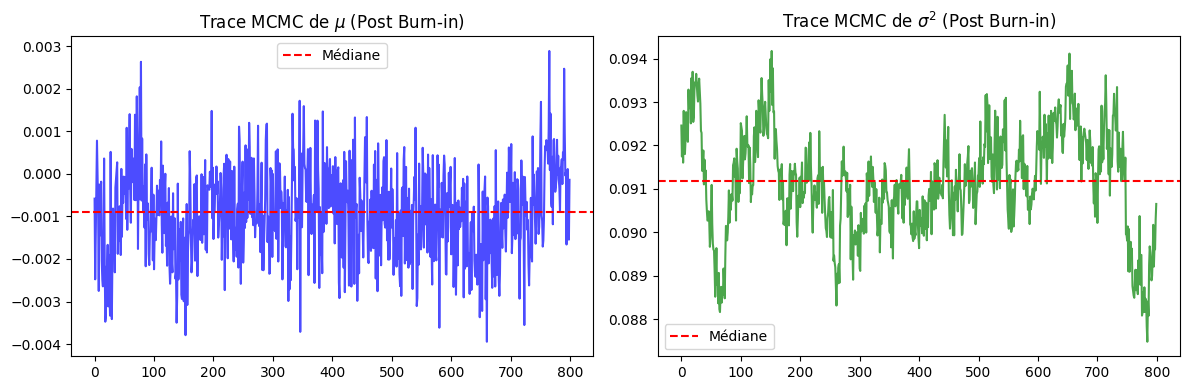

In [13]:
# 1. Amputation du Burn-in (On jette les 20% initiaux où la chaîne "cherche" sa cible)
burn_in = 200
mu_post = np.array(mu[burn_in:])
sigma2_post = np.array(sig[burn_in:])

# 2. Inférence : Calcul des estimateurs et Intervalles de Crédibilité (95%)
mu_median = np.median(mu_post)
mu_ci = np.percentile(mu_post, [2.5, 97.5])

sigma2_median = np.median(sigma2_post)
sigma2_ci = np.percentile(sigma2_post, [2.5, 97.5])

print("=== RÉSULTATS DE L'INFÉRENCE BAYÉSIENNE ===")
print(f"Mu      : {mu_median:.4f}  | IC 95% = [{mu_ci[0]:.4f}, {mu_ci[1]:.4f}]")
print(f"Sigma^2 : {sigma2_median:.4f}  | IC 95% = [{sigma2_ci[0]:.4f}, {sigma2_ci[1]:.4f}]")

# 3. Diagnostics visuels (Trace plots)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Trace de Mu
axes[0].plot(mu_post, alpha=0.7, color='blue')
axes[0].set_title(r"Trace MCMC de $\mu$ (Post Burn-in)")
axes[0].axhline(mu_median, color='red', linestyle='--', label="Médiane")
axes[0].legend()

# Trace de Sigma^2
axes[1].plot(sigma2_post, alpha=0.7, color='green')
axes[1].set_title(r"Trace MCMC de $\sigma^2$ (Post Burn-in)")
axes[1].axhline(sigma2_median, color='red', linestyle='--', label="Médiane")
axes[1].legend()

plt.tight_layout()
plt.show()

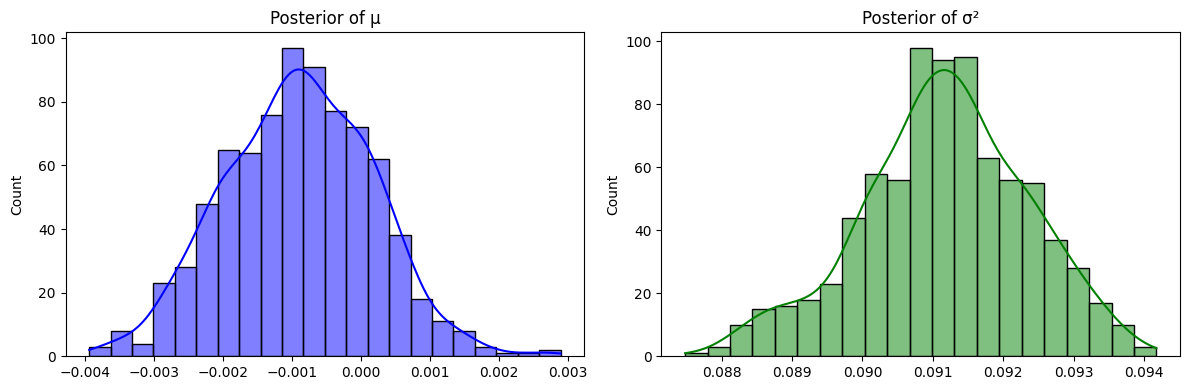

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(mu_post, kde=True, color='blue', ax=axes[0])
axes[0].set_title("Posterior of μ")

sns.histplot(sigma2_post, kde=True, color='green', ax=axes[1])
axes[1].set_title("Posterior of σ²")

plt.tight_layout()
plt.show()